<a href="https://colab.research.google.com/github/Inwobodo/A-Z-Machine-Learning-Capstone-Projects/blob/main/Cohort_Analysis_and_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cohort Analysis and Customer Segmentation

In [243]:
#Import Libraries
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

In [176]:
#Import dataset
df = pd.read_csv('/events.csv')
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


## Exploratory Data Analysis, Data Cleaning and Data Transformation

In [177]:
#Check the dimensions of the dataset
df.shape

(885129, 9)

In [178]:
print(f'The dataset has {df.shape[0]} rows and {df.shape[1]} columns)')

The dataset has 885129 rows and 9 columns)


In [179]:
# Columns in the Dataset
df.columns

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')

In [180]:
# Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885129 entries, 0 to 885128
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     885129 non-null  object 
 1   event_type     885129 non-null  object 
 2   product_id     885129 non-null  int64  
 3   category_id    885129 non-null  int64  
 4   category_code  648910 non-null  object 
 5   brand          672765 non-null  object 
 6   price          885129 non-null  float64
 7   user_id        885129 non-null  int64  
 8   user_session   884964 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 60.8+ MB


In [181]:
#convert the columns to the correct categories
df['product_id']= df['product_id'].astype('str')
df['category_id']= df['category_id'].astype('str')
df['user_id']= df['user_id'].astype('str')

In [182]:
df['event_time'] = pd.to_datetime(df['event_time'])

In [183]:
# Confirm
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885129 entries, 0 to 885128
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   event_time     885129 non-null  datetime64[ns, UTC]
 1   event_type     885129 non-null  object             
 2   product_id     885129 non-null  object             
 3   category_id    885129 non-null  object             
 4   category_code  648910 non-null  object             
 5   brand          672765 non-null  object             
 6   price          885129 non-null  float64            
 7   user_id        885129 non-null  object             
 8   user_session   884964 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(1), object(7)
memory usage: 60.8+ MB


In [184]:
# Descriptive Statistics
df.describe()

,price
count,885129.000000
mean,146.328713
std,296.807683
min,0.220000
25%,26.460000
50%,65.710000
75%,190.490000
max,64771.060000


In [185]:
df.describe(include='object').T

,count,unique,top,freq
event_type,885129,3,view,793748
product_id,885129,53453,1821813,14563
category_id,885129,718,2144415922427789416,116717
category_code,648910,107,computers.components.videocards,116717
brand,672765,999,asus,27706
user_id,885129,407283,1515915625554995474,572
user_session,884964,490398,nFlhu5QzOd,572


In [186]:
df['event_type'].unique()

array(['view', 'cart', 'purchase'], dtype=object)

In [187]:
df['event_time'].describe()

,event_time
count,885129
mean,2020-12-14 11:05:10.680594944+00:00
min,2020-09-24 11:57:06+00:00
25%,2020-11-05 20:48:22+00:00
50%,2020-12-14 15:34:14+00:00
75%,2021-01-23 07:16:12+00:00
max,2021-02-28 23:59:09+00:00


In [188]:
#More descriptive statistics for event time

min_date = df['event_time'].min()
max_date = df['event_time'].max()

# Days difference
diff_days = (max_date - min_date).days

# Months and years difference
rel = relativedelta(max_date, min_date)
diff_years = rel.years
diff_months = rel.years * 12 + rel.months

print(f"Range in days: {diff_days}")
print(f"Range in months: {diff_months}")
print(f"Range in years: {diff_years}")

Range in days: 157
Range in months: 5
Range in years: 0


In [189]:
#Check for duplicates
df.duplicated().sum()

np.int64(655)

In [190]:
df.drop_duplicates(inplace=True, keep='first')

In [191]:
df.duplicated().sum()

np.int64(0)

In [192]:
# The new dimension of our dataset
df.shape

(884474, 9)

In [193]:
#check for missing values
df.isnull().sum().sort_values(ascending=False)

,0
category_code,236047
brand,212232
user_session,162
event_time,0
event_type,0
category_id,0
product_id,0
price,0
user_id,0


In [194]:
df.tail()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
885124,2021-02-28 23:55:01+00:00,view,953226,2144415927553229037,NaN,NaN,219.94,1515915625611023730,FRLqIttxKU
885125,2021-02-28 23:58:05+00:00,view,1715907,2144415927049912542,electronics.video.tv,starwind,80.03,1515915625611024014,g6WqPf50Ma
885126,2021-02-28 23:58:09+00:00,view,4170534,2144415939364389423,electronics.clocks,amazfit,64.92,1515915625611024020,xNIJBqZdkd
885127,2021-02-28 23:58:14+00:00,view,888273,2144415921932861531,electronics.telephone,NaN,10.16,1515915625611024030,9pCbKMIcSx
885128,2021-02-28 23:59:09+00:00,view,743182,2144415935631458761,construction.tools.soldering,kada,65.08,1515915625556087775,BejOXRngEW


##COHORT ANALYSIS

In [195]:
#Let's create a copy of the dataset
data = df.copy()
#Then keep only the columns that are important to cohort analysis. In the RFM stage, we will use this copy
df.drop(['product_id','category_id', 'category_code', \
                         'brand', 'price', 'user_session'], inplace= True, axis = 1)

To create a value that is consistent across all months, the day “01” has been concatenated to the year & month values extracted from event_time. The resulting string has then been converted to a date, which will help with the ordering of data in the later pivot table.

In [196]:
df['current_month'] = df['event_time'].dt.year.map(str) \
                         + "-" + pd.to_datetime(df['event_time']) \
                                 .dt.month.map(str) + "-" '01'

df['current_month'] = pd.to_datetime(df['current_month']).dt.date

From this new column, a cohort_month column can then be created. This is done by first grouping the dataset on user_id. The “min” transformation is then applied to the current_month column, for each grouping.

The minimum here shows us the lowest month for each user. This can be interpreted to mean the first day fo each purchase

In [197]:
df["cohort_month"] = df.groupby("user_id")["current_month"].transform("min")
df.head()

,event_time,event_type,user_id,current_month,cohort_month
0,2020-09-24 11:57:06+00:00,view,1515915625519388267,2020-09-01,2020-09-01
1,2020-09-24 11:57:26+00:00,view,1515915625519380411,2020-09-01,2020-09-01
2,2020-09-24 11:57:27+00:00,view,1515915625513238515,2020-09-01,2020-09-01
3,2020-09-24 11:57:33+00:00,view,1515915625519014356,2020-09-01,2020-09-01
4,2020-09-24 11:57:36+00:00,view,1515915625510743344,2020-09-01,2020-09-01


To continue, we need what is called the cohort index. It is the shows how far from signup each activity was. That is, how many month after signup did that activity happen.

In our case the formula to get that becomes

(Current year - join year)*12 +(current month - join month)

In [198]:
def cohort_index(df, col1, col2):

  current_year = pd.to_datetime(df[col1]).dt.year
  current_month = pd.to_datetime(df[col1]).dt.month
  cohort_year = pd.to_datetime(df[col2]).dt.year
  cohort_month = pd.to_datetime(df[col2]).dt.month
  return (current_year - cohort_year) * 12 + current_month - cohort_month

df['cohort_index'] = cohort_index(df, "current_month", "cohort_month")
df.tail(10)

,event_time,event_type,user_id,current_month,cohort_month,cohort_index
885119,2021-02-28 23:51:08+00:00,view,1515915625611023253,2021-02-01,2021-02-01,0
885120,2021-02-28 23:51:25+00:00,view,1515915625572947504,2021-02-01,2021-01-01,1
885121,2021-02-28 23:51:25+00:00,view,1515915625572947504,2021-02-01,2021-01-01,1
885122,2021-02-28 23:53:13+00:00,view,1515915625611023581,2021-02-01,2021-02-01,0
885123,2021-02-28 23:54:18+00:00,view,1515915625611023671,2021-02-01,2021-02-01,0
885124,2021-02-28 23:55:01+00:00,view,1515915625611023730,2021-02-01,2021-02-01,0
885125,2021-02-28 23:58:05+00:00,view,1515915625611024014,2021-02-01,2021-02-01,0
885126,2021-02-28 23:58:09+00:00,view,1515915625611024020,2021-02-01,2021-02-01,0
885127,2021-02-28 23:58:14+00:00,view,1515915625611024030,2021-02-01,2021-02-01,0
885128,2021-02-28 23:59:09+00:00,view,1515915625556087775,2021-02-01,2020-12-01,2


In [199]:
df['cohort_index'] .unique()

array([0, 1, 2, 3, 4, 5], dtype=int32)

Let's calculate the number of users in each cohort and the number of retained users in each subsequent month. That is, the number of customers that did any activity in the "cohort_index" number of month after signup

In [200]:
cohort_counts = df.groupby(['cohort_month', 'cohort_index'])['user_id'].nunique()

cohort_counts

cohort_month  cohort_index
2020-09-01    0               15334
              1                 955
              2                 267
              3                 119
              4                  98
              5                  72
2020-10-01    0               83261
              1                2227
              2                 678
              3                 444
              4                 279
2020-11-01    0               90106
              1                1867
              2                 792
              3                 552
2020-12-01    0               69473
              1                1644
              2                 710
2021-01-01    0               78278
              1                2162
2021-02-01    0               70831
Name: user_id, dtype: int64

In [201]:
type(cohort_counts)

pandas.core.series.Series

In [202]:
# Turn to dataframe and give correct names. Also ensure that the data is arranged chronologically

cohort_counts_df = cohort_counts.to_frame().rename(columns={'user_id':'users'}) \
                                .sort_values(by=['cohort_month', 'cohort_index'])
cohort_counts_df

users
cohort_month cohort_index       
2020-09-01   0             15334
             1               955
             2               267
             3               119
             4                98
             5                72
2020-10-01   0             83261
             1              2227
             2               678
             3               444
             4               279
2020-11-01   0             90106
             1              1867
             2               792
             3               552
2020-12-01   0             69473
             1              1644
             2               710
2021-01-01   0             78278
             1              2162
2021-02-01   0             70831

In [203]:
type(cohort_counts_df)

pandas.core.frame.DataFrame

## Retention Rate

The retention rate of a cohort can be calculated by dividing the users at each cohort index, by the total number of users in the cohort. The total number of cohort users is retrieved by using the ‘max’ transformation on the users column of each cohort group.

In [204]:
cohort_counts_df['retention_rate'] = cohort_counts_df['users'] / cohort_counts_df \
                  .groupby(["cohort_month"])["users"].transform("max")
cohort_counts_df

users  retention_rate
cohort_month cohort_index                       
2020-09-01   0             15334        1.000000
             1               955        0.062280
             2               267        0.017412
             3               119        0.007761
             4                98        0.006391
             5                72        0.004695
2020-10-01   0             83261        1.000000
             1              2227        0.026747
             2               678        0.008143
             3               444        0.005333
             4               279        0.003351
2020-11-01   0             90106        1.000000
             1              1867        0.020720
             2               792        0.008790
             3               552        0.006126
2020-12-01   0             69473        1.000000
             1              1644        0.023664
             2               710        0.010220
2021-01-01   0             78278        1.000000
             1              2162        0.027620
2021-02-01   0             70831        1.000000

In [205]:
cohorts_pivot = cohort_counts_df.pivot_table(index='cohort_month', columns = 'cohort_index', values = 'retention_rate')
cohorts_pivot

cohort_index,0,1,2,3,4,5
cohort_month,,,,,,
2020-09-01,1.0,0.062280,0.017412,0.007761,0.006391,0.004695
2020-10-01,1.0,0.026747,0.008143,0.005333,0.003351,NaN
2020-11-01,1.0,0.020720,0.008790,0.006126,NaN,NaN
2020-12-01,1.0,0.023664,0.010220,NaN,NaN,NaN
2021-01-01,1.0,0.027620,NaN,NaN,NaN,NaN
2021-02-01,1.0,NaN,NaN,NaN,NaN,NaN


## Visualizing the result of our analysis

<Axes: xlabel='cohort_index', ylabel='cohort_month'>

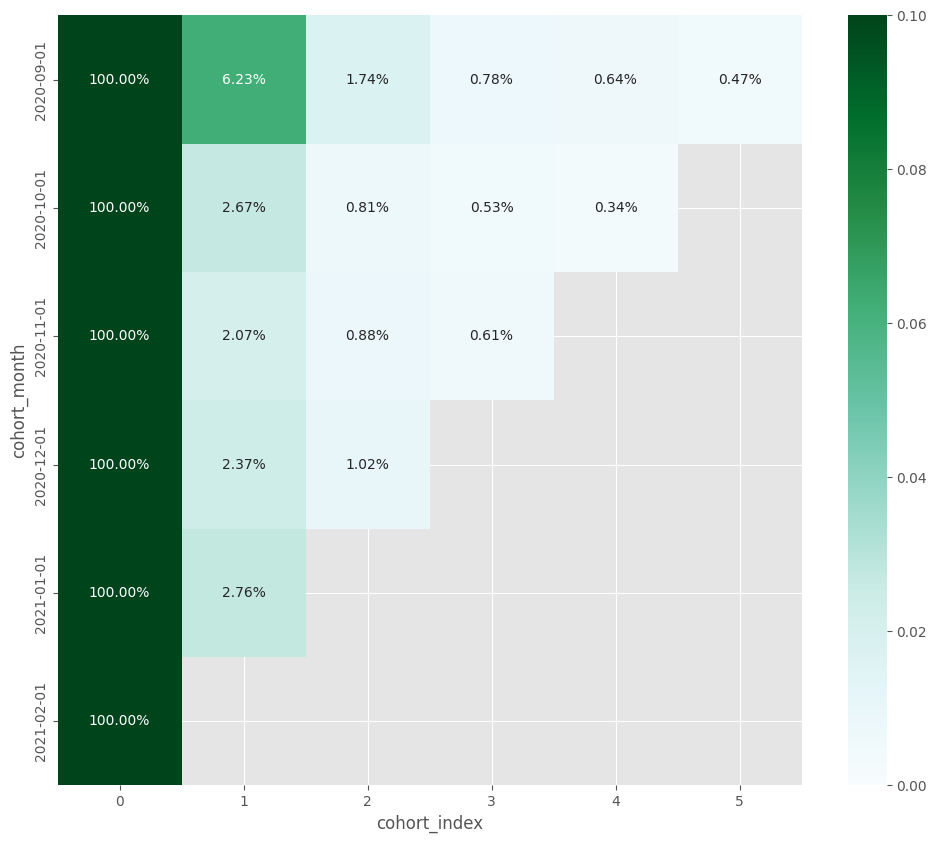

In [241]:
plt.figure(figsize = (12, 10))
sns.heatmap(data = cohorts_pivot,
            annot = True,
            fmt = '.2%',
            vmin = 0.0,
            vmax = 0.1,
            cmap = 'BuGn')

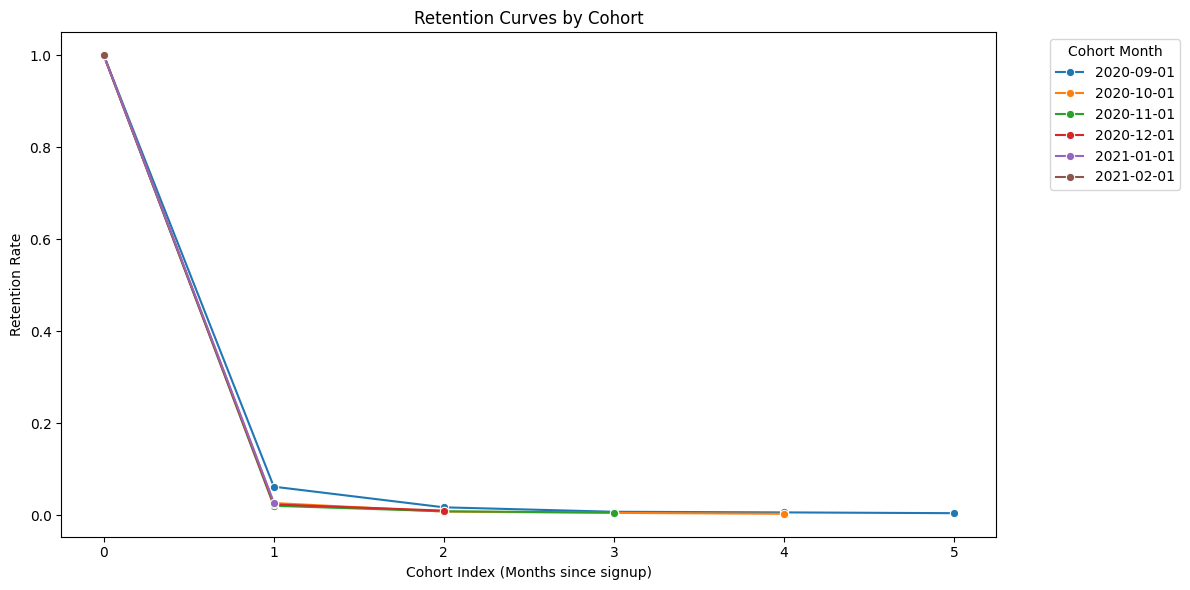

In [207]:

plt.figure(figsize=(12,6))
sns.lineplot(
    data=cohort_counts_df,
    x="cohort_index",
    y="retention_rate",
    hue="cohort_month",
    marker="o"
)

plt.title("Retention Curves by Cohort")
plt.xlabel("Cohort Index (Months since signup)")
plt.ylabel("Retention Rate")
plt.legend(title="Cohort Month", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# Go to slide to look at recommendations based on the visualizations

# CUSTOMER SEGMENTATION

***Customer segmentation*** is the process of dividing customers into groups based on shared characteristics — such as behavior, demographics, or value — so businesses can better understand and serve them.

In product data science, one of the easiest ways to understand and categorize customers is through RFM analysis. RFM stands for Recency, Frequency and Monetary value which are three simple ways to look at customer behaviour:

***Recency:*** How recently did the customer make a purchase? The more recent, the more engaged they are.

***Frequency:*** How often do they buy from you? Customers who buy often are more loyal.

***Monetary:*** How much does the customer spend? High spenders are usually more valuable.

# RECENCY

In [208]:
df_recency = df.groupby(by='user_id', as_index=False)['event_time'].max()
df_recency.columns = ['user_id', 'LastPurchaseDate']

df_recency.head()

,user_id,LastPurchaseDate
0,1515915625353226922,2020-10-29 11:28:35+00:00
1,1515915625353230067,2020-10-06 06:30:32+00:00
2,1515915625353230683,2020-12-12 10:33:09+00:00
3,1515915625353230922,2020-10-02 08:23:40+00:00
4,1515915625353234047,2021-02-18 09:11:44+00:00


In [209]:
recent_date = df_recency['LastPurchaseDate'].max()
df_recency['Recency'] = df_recency['LastPurchaseDate'].apply(lambda x: (recent_date - x).days)
df_recency.head()

,user_id,LastPurchaseDate,Recency
0,1515915625353226922,2020-10-29 11:28:35+00:00,122
1,1515915625353230067,2020-10-06 06:30:32+00:00,145
2,1515915625353230683,2020-12-12 10:33:09+00:00,78
3,1515915625353230922,2020-10-02 08:23:40+00:00,149
4,1515915625353234047,2021-02-18 09:11:44+00:00,10


#FREQUENCY

In [210]:
frequency_df = df.groupby(by=['user_id'], as_index=False)['event_time'].count()
frequency_df.columns = ['user_id', 'Frequency']
frequency_df.head()

,user_id,Frequency
0,1515915625353226922,1
1,1515915625353230067,1
2,1515915625353230683,13
3,1515915625353230922,1
4,1515915625353234047,36


#MONETARY

In [211]:
data.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27+00:00,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36+00:00,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


In [218]:
# filter only purchases
purchases = data[data['event_type'] == 'purchase']

# aggregate by user: sum of all product prices they bought
monetary_df = purchases.groupby('user_id')['price'].sum().reset_index()

# rename
monetary_df.rename(columns={'price': 'Monetary'}, inplace=True)

monetary_df.head()

,user_id,Monetary
0,1515915625353286099,119.03
1,1515915625353457259,55.16
2,1515915625353534622,57.15
3,1515915625353561691,345.72
4,1515915625353900095,57.85


In [222]:
rf_df = df_recency.merge(frequency_df, on='user_id')
rfm_df = rf_df.merge(monetary_df, on='user_id').drop(columns='LastPurchaseDate')
rfm_df.head()

,user_id,Recency,Frequency,Monetary
0,1515915625353286099,128,11,119.03
1,1515915625353457259,152,3,55.16
2,1515915625353534622,136,10,57.15
3,1515915625353561691,95,10,345.72
4,1515915625353900095,133,40,57.85


In [224]:
rfm_df['R_rank'] = rfm_df['Recency'].rank(ascending=False)
rfm_df['F_rank'] = rfm_df['Frequency'].rank(ascending=True)
rfm_df['M_rank'] = rfm_df['Monetary'].rank(ascending=True)
rfm_df.head()

,user_id,Recency,Frequency,Monetary,R_rank,F_rank,M_rank
0,1515915625353286099,128,11,119.03,3048.5,17108.0,11847.0
1,1515915625353457259,152,3,55.16,400.0,2407.0,8079.5
2,1515915625353534622,136,10,57.15,2026.5,16416.5,8334.0
3,1515915625353561691,95,10,345.72,7627.5,16416.5,16816.0
4,1515915625353900095,133,40,57.85,2382.5,20919.5,8386.0


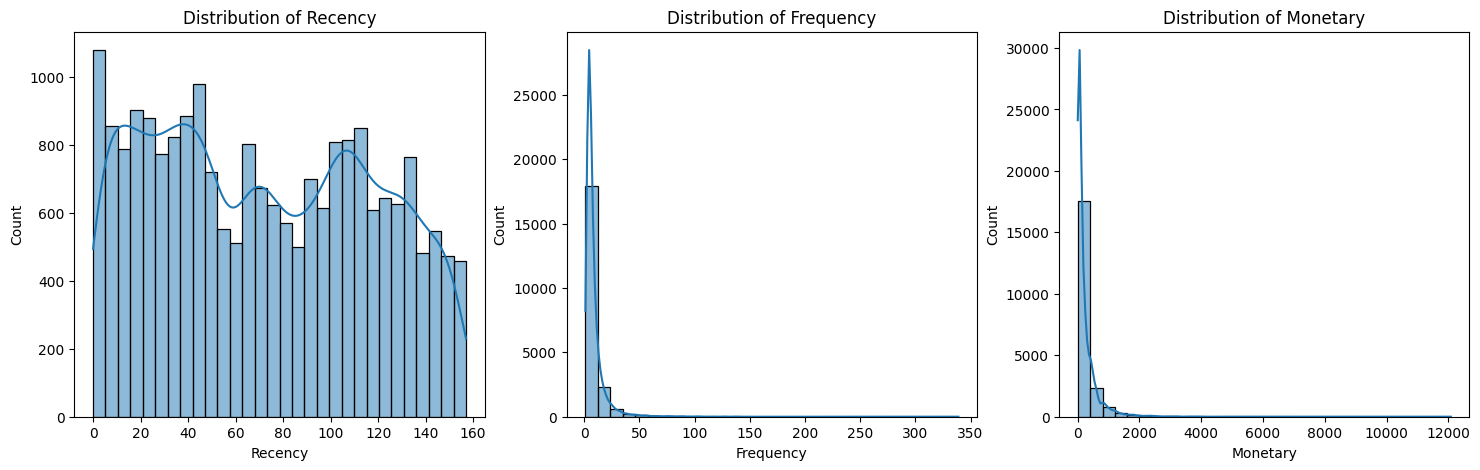

In [248]:

fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.histplot(rfm_df['Recency'], bins=30, ax=axes[0], kde=True)
axes[0].set_title("Distribution of Recency")

sns.histplot(rfm_df['Frequency'], bins=30, ax=axes[1], kde=True)
axes[1].set_title("Distribution of Frequency")

sns.histplot(rfm_df['Monetary'], bins=30, ax=axes[2], kde=True)
axes[2].set_title("Distribution of Monetary")

plt.show()


In [225]:
rfm_df['R_rank_norm'] = (rfm_df['R_rank'] / rfm_df['R_rank'].max()) * 100
rfm_df['F_rank_norm'] = (rfm_df['F_rank'] / rfm_df['F_rank'].max()) * 100
rfm_df['M_rank_norm'] = (rfm_df['M_rank'] / rfm_df['M_rank'].max()) * 100
rfm_df.head()

,user_id,Recency,Frequency,Monetary,R_rank,F_rank,M_rank,R_rank_norm,F_rank_norm,M_rank_norm
0,1515915625353286099,128,11,119.03,3048.5,17108.0,11847.0,14.374632,80.304168,55.609275
1,1515915625353457259,152,3,55.16,400.0,2407.0,8079.5,1.886125,11.298348,37.924803
2,1515915625353534622,136,10,57.15,2026.5,16416.5,8334.0,9.555582,77.058299,39.119414
3,1515915625353561691,95,10,345.72,7627.5,16416.5,16816.0,35.966050,77.058299,78.933534
4,1515915625353900095,133,40,57.85,2382.5,20919.5,8386.0,11.234233,98.195175,39.363500


In [226]:
rfm_df['RFM_Score'] = 0.15 * rfm_df['R_rank_norm'] + 0.28 * rfm_df['F_rank_norm'] + 0.57 * rfm_df['M_rank_norm']
rfm_df['RFM_Score'] *= 0.05
rfm_df = rfm_df.round(2)
rfm_df.head()

,user_id,Recency,Frequency,Monetary,R_rank,F_rank,M_rank,R_rank_norm,F_rank_norm,M_rank_norm,RFM_Score
0,1515915625353286099,128,11,119.03,3048.5,17108.0,11847.0,14.37,80.30,55.61,2.82
1,1515915625353457259,152,3,55.16,400.0,2407.0,8079.5,1.89,11.30,37.92,1.25
2,1515915625353534622,136,10,57.15,2026.5,16416.5,8334.0,9.56,77.06,39.12,2.27
3,1515915625353561691,95,10,345.72,7627.5,16416.5,16816.0,35.97,77.06,78.93,3.60
4,1515915625353900095,133,40,57.85,2382.5,20919.5,8386.0,11.23,98.20,39.36,2.58


In [227]:
rfm_df[['user_id', 'RFM_Score']].head(7)

,user_id,RFM_Score
0,1515915625353286099,2.82
1,1515915625353457259,1.25
2,1515915625353534622,2.27
3,1515915625353561691,3.60
4,1515915625353900095,2.58
5,1515915625354176736,3.17
6,1515915625354561351,3.07


In [228]:
rfm_df["Customer_segment"] = np.where(rfm_df['RFM_Score'] > 4.5, "Top Customers",
                                       np.where(rfm_df['RFM_Score'] > 4, "High value Customer",
                                                np.where(rfm_df['RFM_Score'] > 3, "Medium Value Customer",
                                                         np.where(rfm_df['RFM_Score'] > 1.6, 'Low Value Customers', 'Lost Customers'))))

In [231]:
rfm_df[['user_id', 'RFM_Score', 'Customer_segment']].head(10)

,user_id,RFM_Score,Customer_segment
0,1515915625353286099,2.82,Low Value Customers
1,1515915625353457259,1.25,Lost Customers
2,1515915625353534622,2.27,Low Value Customers
3,1515915625353561691,3.60,Medium Value Customer
4,1515915625353900095,2.58,Low Value Customers
5,1515915625354176736,3.17,Medium Value Customer
6,1515915625354561351,3.07,Medium Value Customer
7,1515915625354822642,3.14,Medium Value Customer
8,1515915625354857951,3.50,Medium Value Customer
9,1515915625355179497,3.60,Medium Value Customer


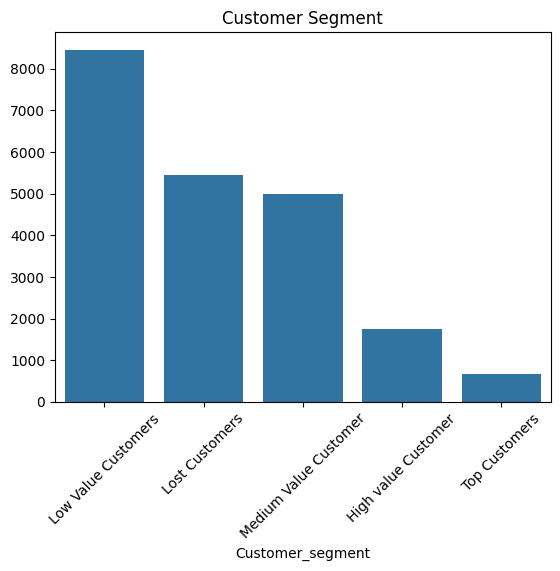

In [244]:
customer_segment = rfm_df.Customer_segment.value_counts()
sns.barplot(x=customer_segment.index, y=customer_segment.values)
plt.title('Customer Segment')
plt.xticks(rotation=45)
plt.show()